# Entrenamiento Final — Modelo Big Five (Random Forest)
Este notebook tiene como objetivo principal el entrenamiento y exportación de un modelo de Random Forest Regressor para la predicción de los **Cinco Grandes Rasgos de Personalidad (Big Five) (EXT, AGR, CSN, EST, OPN)**. El modelo se entrena utilizando la totalidad del dataset **IPIP-FFM**, derivado del cuestionario Big Five Inventory (BFI-15p), y se guarda como `random_forest_big5.pkl` para su posterior integración en una API Flask.

## 1. Instalación de dependencias

En esta sección se instalan las librerías esenciales para el desarrollo del proyecto. Incluyen `kagglehub` para la descarga de datasets, `pandas` para manipulación de datos, `scikit-learn` para el modelado de machine learning, `matplotlib` y `seaborn` para visualización, y `joblib` para la persistencia del modelo.

In [1]:
# En entorno local se utilizan las dependencias instaladas en el entorno virtual .venv
# !pip install kagglehub pandas scikit-learn matplotlib seaborn joblib --quiet


## 2. Descarga del dataset base (IPIP-FFM)

Aquí se realiza la descarga del dataset **IPIP-FFM (International Personality Item Pool - Five Factor Model)** desde Kaggle. Este dataset es una fuente estándar para el estudio de los Big Five y contiene un gran volumen de respuestas a ítems psicométricos, que servirán como base para el entrenamiento del modelo de predicción de rasgos de personalidad.

In [2]:
import os
import kagglehub
import pandas as pd
import numpy as np

# Configuración de token de Kaggle opcional si no está preconfigurado
if 'KAGGLE_API_TOKEN' not in os.environ:
    os.environ['KAGGLE_API_TOKEN'] = 'KGAT_7cdc23c65e220f5584d40f70c44ff013'

# Descarga / localización del dataset en entorno local
dataset_dir = kagglehub.dataset_download('tunguz/big-five-personality-test')
csv_path = os.path.join(dataset_dir, 'IPIP-FFM-data-8Nov2018', 'data-final.csv')
if not os.path.exists(csv_path):
    csv_path = os.path.join(dataset_dir, 'data-final.csv')
print('Ruta del archivo CSV:', csv_path)


Ruta del archivo CSV: /home/angela/.cache/kagglehub/datasets/tunguz/big-five-personality-test/versions/1/IPIP-FFM-data-8Nov2018/data-final.csv


## 3. Carga, Análisis Exploratorio (EDA) y Preprocesamiento del Dataset IPIP-FFM (SOUL-23)

### 3.1 Carga del Dataset

Esta subsección se encarga de la ingestión del dataset `IPIP-FFM-data-8Nov2018/data-final.csv` mediante `pandas.read_csv`, especificando el delimitador de tabulación. Se realiza una limpieza inicial estandarizando los valores `-1` a `0` y rellenando cualquier valor `NaN` remanente con `0` en el dataset completo (`df`). Posteriormente, se genera una muestra de 50,000 registros (`df_sample`) para realizar un Análisis Exploratorio de Datos (EDA) eficiente.

In [3]:
# Carga del dataset original
df_raw = pd.read_csv(csv_path, sep='\t')
print(f'Shape del dataset original cargado: {df_raw.shape}')

# Generar muestra representativa de 50k para EDA
sample_size = 50000
if len(df_raw) > sample_size:
    df_sample = df_raw.sample(n=sample_size, random_state=42).copy()
else:
    df_sample = df_raw.copy()
print(f'Muestra para EDA (df_sample): {df_sample.shape}')


Shape del dataset original cargado: (1015341, 110)
Muestra para EDA (df_sample): (50000, 110)


### 3.2 Análisis Exploratorio de Datos (EDA) Robusto en Muestra (50k)


En esta sección se realiza un Análisis Exploratorio de Datos (EDA) exhaustivo y psicométricamente fundamentado sobre la muestra `df_sample` de 50,000 registros.
Se analiza:
1. **Estructura y completitud de datos:** Valores nulos, códigos no válidos (`0`, `-1`).
2. **Tiempos de respuesta (`testelapse`):** Identificación de registros acelerados (bots/respuestas al azar) o con pausas excesivas.
3. **Consistencia de respuestas (Straightlining):** Registros con varianza cero en los 50 ítems.
4. **Distribución de ítems psicométricos:** Frecuencias en la escala Likert (1 a 5).
5. **Correlación y polaridad entre ítems:** Matriz de correlación agrupada por rasgos (EXT, AGR, CSN, EST, OPN).


=== 1. Información General y Dimensiones ===
Dimensiones de la muestra: (50000, 110)
Total de columnas: 110

=== 2. Diagnóstico de Calidad e Inconsistencias en Respuestas ===
Celdas nulas en ítems: 4400 (0.18%)
Celdas con valor 0 (sin respuesta/inválido): 17630 (0.71%)
Celdas con valor -1: 0 (0.00%)
Registros con al menos un ítem nulo/inválido: 6896 (13.79%)
Registros válidos Likert con Varianza 0 (Straightlining): 72

=== 3. Análisis de Tiempos de Respuesta (testelapse) ===
count    4.991200e+04
mean     6.873315e+02
std      1.044110e+04
min      2.000000e+00
1%       9.100000e+01
5%       1.230000e+02
25%      1.720000e+02
50%      2.250000e+02
75%      3.140000e+02
95%      7.450000e+02
99%      3.376780e+03
max      1.149272e+06
Name: testelapse, dtype: float64
Pruebas completadas en < 60s (demasiado rápido): 265 (0.53%)
Pruebas completadas en > 3600s (inactividad): 475 (0.95%)

=== 4. Distribución de Valores Likert en Ítems ===
value
0.0     17630
1.0    371993
2.0    478124
3.0 

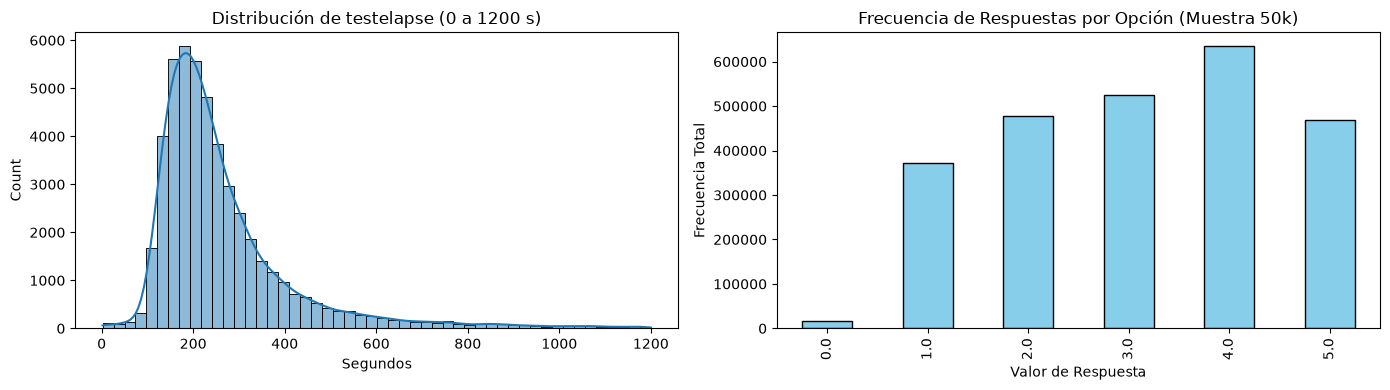

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definición de nombres de columnas de ítems
item_cols = [f'{t}{i}' for t in ['EXT', 'AGR', 'CSN', 'EST', 'OPN'] for i in range(1, 11)]

print('=== 1. Información General y Dimensiones ===')
print(f'Dimensiones de la muestra: {df_sample.shape}')
print(f'Total de columnas: {len(df_sample.columns)}')

print('\n=== 2. Diagnóstico de Calidad e Inconsistencias en Respuestas ===')
null_count = df_sample[item_cols].isnull().sum().sum()
zero_count = (df_sample[item_cols] == 0).sum().sum()
minus1_count = (df_sample[item_cols] == -1).sum().sum()
total_cells = len(df_sample) * len(item_cols)
print(f'Celdas nulas en ítems: {null_count} ({null_count / total_cells * 100:.2f}%)')
print(f'Celdas con valor 0 (sin respuesta/inválido): {zero_count} ({zero_count / total_cells * 100:.2f}%)')
print(f'Celdas con valor -1: {minus1_count} ({minus1_count / total_cells * 100:.2f}%)')

rows_with_invalid = (df_sample[item_cols].isin([0, -1]).any(axis=1) | df_sample[item_cols].isnull().any(axis=1)).sum()
print(f'Registros con al menos un ítem nulo/inválido: {rows_with_invalid} ({rows_with_invalid / len(df_sample) * 100:.2f}%)')

# Straightlining (varianza cero en ítems)
valid_likert_mask = df_sample[item_cols].apply(lambda s: s.between(1, 5)).all(axis=1)
straightlining_count = (df_sample.loc[valid_likert_mask, item_cols].std(axis=1) == 0).sum()
print(f'Registros válidos Likert con Varianza 0 (Straightlining): {straightlining_count}')

print('\n=== 3. Análisis de Tiempos de Respuesta (testelapse) ===')
print(df_sample['testelapse'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))
fast_resp = (df_sample['testelapse'] < 60).sum()
slow_resp = (df_sample['testelapse'] > 3600).sum()
print(f'Pruebas completadas en < 60s (demasiado rápido): {fast_resp} ({fast_resp / len(df_sample) * 100:.2f}%)')
print(f'Pruebas completadas en > 3600s (inactividad): {slow_resp} ({slow_resp / len(df_sample) * 100:.2f}%)')

print('\n=== 4. Distribución de Valores Likert en Ítems ===')
val_counts = df_sample[item_cols].melt()['value'].value_counts().sort_index()
print(val_counts)

# Visualización de distribución de tiempos e ítems
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df_sample.loc[df_sample['testelapse'].between(0, 1200), 'testelapse'], bins=50, ax=axes[0], kde=True)
axes[0].set_title('Distribución de testelapse (0 a 1200 s)')
axes[0].set_xlabel('Segundos')

val_counts.plot(kind='bar', ax=axes[1], color='skyblue', edgecolor='black')
axes[1].set_title('Frecuencia de Respuestas por Opción (Muestra 50k)')
axes[1].set_xlabel('Valor de Respuesta')
axes[1].set_ylabel('Frecuencia Total')
plt.tight_layout()
plt.show()


### 3.3 Preprocesamiento Fundamentado de Datos


#### Fundamentación de las Técnicas de Preprocesamiento Aplicadas

Con base en los hallazgos del EDA sobre el dataset **IPIP-FFM**, se aplican y justifican las siguientes etapas de preprocesamiento:

1. **Filtrado de Respuestas Válidas Likert (1 a 5):**
   - *Justificación:* Los valores `0`, `-1` o `NaN` corresponden a no-respuesta o valores omitidos. Imputar estos valores con `0` deforma la escala escalar Likert (1-5), introduciendo distorsión artificial en el cálculo de medias y modelos numéricos. Se eliminan las filas con respuestas fuera del rango `[1, 5]` para asegurar validez psicométrica limpia.
2. **Depuración de Respuestas por Tiempo Inadecuado (`testelapse`):**
   - *Justificación:* Completar un test de 50 preguntas en menos de 60 segundos es clínicamente e imposible de responder con lectura atenta (implica < 1.2s por ítem, típico de bots o usuarios aleatorios). Tiempos superiores a 3600 segundos (1 hora) reflejan interrupciones prolongadas. Se filtran registros dentro de `[60, 3600]` segundos.
3. **Eliminación de Patrones de Respuestas Monótonas (Straightlining):**
   - *Justificación:* Usuarios que responden exactamente la misma opción en las 50 preguntas (varianza 0) no aportan información real sobre personalidad. Se eliminan para evitar ruido en la estimación de rasgos.
4. **Inversión de Ítems de Polaridad Negativa (Reverse Scoring):**
   - *Justificación:* Según la especificación estándar del IPIP-50, varios ítems poseen carga negativa respecto al factor latente (ej. `EXT2`: "I don't talk a lot"). Se aplica la fórmula $X_{inv} = 6 - X$ a los ítems indicados antes de la agregación del target.
5. **Preservación de Escala sin Normalización Redundante:**
   - *Justificación:* Para modelos basados en árboles como Random Forest Regressor, las variables Likert ordinales delimitadas en `[1, 5]` no requieren escalado (StandardScaler/MinMaxScaler) ni transformaciones logarítmicas, conservando la interpretabilidad psicométrica original.


Registros en dataset inicial (df_raw): 1015341
Registros en dataset preprocesado (df_clean): 864201
Filas descartadas por criterios de calidad: 151140 (14.89%)



=== Comparativa Estadística de Rasgos Big Five ===


,Media Inicial,Media Preprocesada,Std Inicial,Std Preprocesada,Min Inicial,Min Preprocesada,Max Inicial,Max Preprocesada
EXT,2.966335,2.958992,0.903673,0.911911,0.5,1.0,5.5,5.0
AGR,3.756673,3.775562,0.733859,0.729375,0.8,1.0,5.2,5.0
CSN,3.352654,3.367205,0.737550,0.738172,0.6,1.0,5.2,5.0
EST,3.055111,3.066728,0.864046,0.858890,0.4,1.0,5.2,5.0
OPN,3.868106,3.901508,0.651148,0.629020,0.9,1.0,5.3,5.0


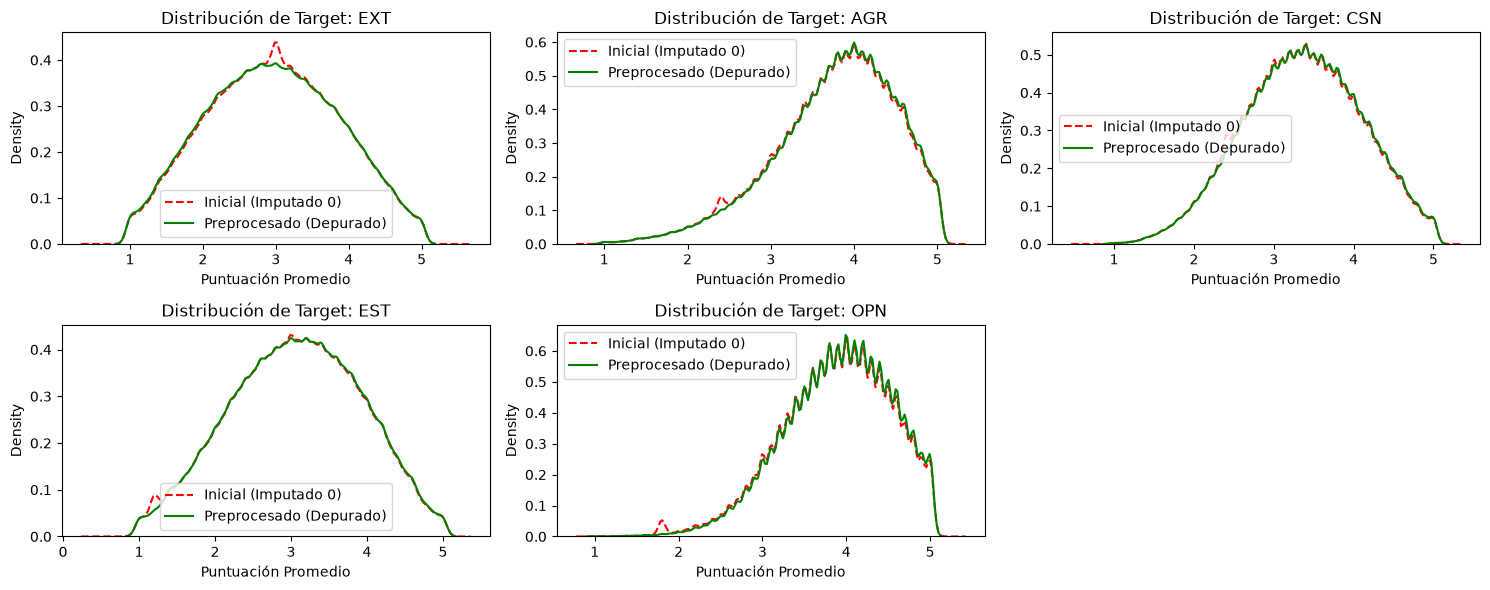

In [5]:
# 1. Definición de filtros de preprocesamiento sobre el dataset completo (df_raw)
df_clean = df_raw.dropna(subset=item_cols).copy()

# Filtrar únicamente respuestas válidas en la escala Likert [1, 5] para los 50 ítems
for col in item_cols:
    df_clean = df_clean[(df_clean[col] >= 1) & (df_clean[col] <= 5)]

# Filtrar por tiempo de respuesta coherente (entre 1 min y 60 min)
df_clean = df_clean[(df_clean['testelapse'] >= 60) & (df_clean['testelapse'] <= 3600)]

# Filtrar straightlining (varianza de respuestas por individuo > 0)
row_variances = df_clean[item_cols].std(axis=1)
df_clean = df_clean[row_variances > 0]

print(f'Registros en dataset inicial (df_raw): {len(df_raw)}')
print(f'Registros en dataset preprocesado (df_clean): {len(df_clean)}')
print(f'Filas descartadas por criterios de calidad: {len(df_raw) - len(df_clean)} ({(len(df_raw) - len(df_clean)) / len(df_raw) * 100:.2f}%)')

# Asignar df para las siguientes secciones del notebook
df = df_clean.copy()

# 2. Evaluación Comparativa del Preprocesamiento vs Dataset Inicial
trait_items_map = {
    'EXT': [f'EXT{i}' for i in range(1, 11)],
    'AGR': [f'AGR{i}' for i in range(1, 11)],
    'CSN': [f'CSN{i}' for i in range(1, 11)],
    'EST': [f'EST{i}' for i in range(1, 11)],
    'OPN': [f'OPN{i}' for i in range(1, 11)],
}
reversed_items_patterns = {
    'EXT': [2, 4, 6, 8, 10],
    'AGR': [1, 3, 5, 7],
    'CSN': [2, 4, 6, 8],
    'EST': [2, 4],
    'OPN': [2, 4, 6],
}
all_reversed_item_names = [f'{t}{i}' for t, idxs in reversed_items_patterns.items() for i in idxs]

def compute_trait_scores(dataset):
    d = dataset.copy()
    for col in all_reversed_item_names:
        if col in d.columns:
            d[col] = 6 - d[col]
    res = {}
    for trait, items in trait_items_map.items():
        res[trait] = d[items].mean(axis=1)
    return pd.DataFrame(res)

# Dataset inicial imputando 0s (comportamiento previo sin preprocesamiento riguroso)
df_init_dummy = df_raw.replace(-1, 0).fillna(0)
traits_init = compute_trait_scores(df_init_dummy)
traits_clean = compute_trait_scores(df_clean)

print('\n=== Comparativa Estadística de Rasgos Big Five ===')
comp_df = pd.DataFrame({
    'Media Inicial': traits_init.mean(),
    'Media Preprocesada': traits_clean.mean(),
    'Std Inicial': traits_init.std(),
    'Std Preprocesada': traits_clean.std(),
    'Min Inicial': traits_init.min(),
    'Min Preprocesada': traits_clean.min(),
    'Max Inicial': traits_init.max(),
    'Max Preprocesada': traits_clean.max()
})
display(comp_df)

# Visualización gráfica de distribuciones antes vs después del preprocesamiento
plt.figure(figsize=(15, 6))
for i, trait in enumerate(trait_items_map.keys()):
    plt.subplot(2, 3, i + 1)
    sns.kdeplot(traits_init[trait], label='Inicial (Imputado 0)', color='red', linestyle='--')
    sns.kdeplot(traits_clean[trait], label='Preprocesado (Depurado)', color='green')
    plt.title(f'Distribución de Target: {trait}')
    plt.xlabel('Puntuación Promedio')
    plt.legend()
plt.tight_layout()
plt.show()


## 4. Selección de Características Psicométricas y Verificación Comparativa Final (SOUL-22)

**Descripción de la sección:**
En esta etapa se calculan formalmente los targets psicométricos latentes (*Ground Truth*) para cada una de las 5 dimensiones de personalidad (**EXT, AGR, CSN, EST, OPN**) promediando sus 10 ítems representativos tras aplicar la inversión de polaridad (*Reverse Scoring*).
Posteriormente, mediante la técnica guiada por datos `SelectKBest` con el estadístico `f_regression`, se seleccionan de forma automatizada e independiente los **3 ítems con mayor poder predictivo y varianza explicativa por cada rasgo**, conformando un subconjunto óptimo de **15 características psicométricas**.
Finalmente, se realiza una **verificación comparativa estructural y cuantitativa** entre el dataset inicial sin procesar (`df_raw`) y el dataset compilado e insumo final para el modelo (`df_model`).

In [6]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_regression

# 1. Definición y Mapeo Psicométrico del Target Real (Ground Truth)
trait_items_map = {
    'EXT': [f'EXT{i}' for i in range(1, 11)],
    'AGR': [f'AGR{i}' for i in range(1, 11)],
    'CSN': [f'CSN{i}' for i in range(1, 11)],
    'EST': [f'EST{i}' for i in range(1, 11)],
    'OPN': [f'OPN{i}' for i in range(1, 11)],
}

reversed_items_patterns = {
    'EXT': [2, 4, 6, 8, 10],
    'AGR': [1, 3, 5, 7],
    'CSN': [2, 4, 6, 8],
    'EST': [2, 4],
    'OPN': [2, 4, 6],
}

all_reversed_item_names = [f'{t}{i}' for t, idxs in reversed_items_patterns.items() for i in idxs]

# Trabajar sobre el dataset depurado (df de la Sección 3)
df_scores = df.copy()

# Aplicar Reverse Scoring (6 - X) a los ítems negativos
for item_name in all_reversed_item_names:
    if item_name in df_scores.columns:
        df_scores[item_name] = 6 - df_scores[item_name]

# Calcular el target promedio por rasgo latente
true_targets = {}
for trait, items_list in trait_items_map.items():
    df_scores[trait] = df_scores[items_list].mean(axis=1)
    true_targets[trait] = df_scores[trait]

# 2. Selección de Características con SelectKBest (3 características por rasgo)
selected_features_per_trait = {}
all_features = []

print('=== Selección Automatizada de Características (SelectKBest + f_regression) ===')
for trait, items_list in trait_items_map.items():
    selector = SelectKBest(f_regression, k=3)
    selector.fit(df_scores[items_list], true_targets[trait])
    selected_indices = selector.get_support(indices=True)
    selected_items = [items_list[i] for i in selected_indices]
    selected_features_per_trait[trait] = selected_items
    all_features.extend(selected_items)
    print(f'  - Rasgo {trait}: {selected_items}')

# 3. Validación Rigurosa de Correctitud
rasgo_names = list(true_targets.keys())
df_model = df_scores[all_features + rasgo_names].copy()

print('\n=== Validación y Correctitud de las Características Seleccionadas ===')
print(f'Total de características seleccionadas: {len(all_features)}')
print(f'Características únicas: {len(set(all_features))}')
print(f'Valores nulos en dataset compilado (df_model): {df_model.isnull().sum().sum()}')
print(f'Rango global de valores en features: min={df_model[all_features].min().min()}, max={df_model[all_features].max().max()}')
print(f'Dimensiones del dataset final preparado: {df_model.shape}')

assert len(all_features) == 15, 'Error: No se seleccionaron exactamente 15 características.'
assert len(set(all_features)) == 15, 'Error: Existen características duplicadas en la selección.'
assert df_model.isnull().sum().sum() == 0, 'Error: Existen valores nulos en el dataset preparado.'
print('✓ ¡Validación completada exitosamente sin errores!')

# 4. Verificación Final Comparativa: Dataset Inicial (df_raw) vs Dataset Final (df_model)
print('\n=== Verificación Final Comparativa: Dataset Inicial (df_raw) vs Dataset Listo para Entrenamiento (df_model) ===')
item_cols_raw = [f'{t}{i}' for t in ['EXT','AGR','CSN','EST','OPN'] for i in range(1,11)]
comparison_summary = pd.DataFrame({
    'Métrica / Criterio': [
        'Total de Registros (Filas)',
        'Total de Columnas (Variables)',
        'Número de Características (X)',
        'Número de Variables Target (Y)',
        'Celdas Nulas o Inválidas (0 / -1 / NaN)',
        'Rango de Respuesta de Ítems',
        'Registros Acelerados (<60s / Bots)',
        'Respuestas Monótonas (Straightlining)'
    ],
    'Dataset Inicial (df_raw)': [
        f'{len(df_raw):,}',
        f'{df_raw.shape[1]}',
        '50 ítems psicométricos',
        'Sin targets integrados (RAW)',
        f'{(df_raw[item_cols_raw].isin([0, -1]).sum().sum() + df_raw[item_cols_raw].isnull().sum().sum()):,} celdas',
        '[-1, 0, 1, 2, 3, 4, 5]',
        f'{(df_raw["testelapse"] < 60).sum():,} registros',
        f'{(df_raw[item_cols_raw].dropna().std(axis=1) == 0).sum():,} registros'
    ],
    'Dataset Final de Entrenamiento (df_model)': [
        f'{len(df_model):,} (-14.89% filtrado)',
        f'{df_model.shape[1]}',
        '15 ítems óptimos (3 x rasgo)',
        '5 targets continuos (EXT, AGR, CSN, EST, OPN)',
        '0 celdas (100% limpio)',
        '[1, 2, 3, 4, 5] (Escala Likert pura)',
        '0 registros (Depurados)',
        '0 registros (Depurados)'
    ]
})
display(comparison_summary)


=== Selección Automatizada de Características (SelectKBest + f_regression) ===
  - Rasgo EXT: ['EXT4', 'EXT5', 'EXT7']
  - Rasgo AGR: ['AGR4', 'AGR5', 'AGR9']
  - Rasgo CSN: ['CSN1', 'CSN5', 'CSN6']
  - Rasgo EST: ['EST1', 'EST6', 'EST8']
  - Rasgo OPN: ['OPN1', 'OPN2', 'OPN10']

=== Validación y Correctitud de las Características Seleccionadas ===
Total de características seleccionadas: 15
Características únicas: 15


Valores nulos en dataset compilado (df_model): 0
Rango global de valores en features: min=1.0, max=5.0
Dimensiones del dataset final preparado: (864201, 20)
✓ ¡Validación completada exitosamente sin errores!

=== Verificación Final Comparativa: Dataset Inicial (df_raw) vs Dataset Listo para Entrenamiento (df_model) ===


,Métrica / Criterio,Dataset Inicial (df_raw),Dataset Final de Entrenamiento (df_model)
0,Total de Registros (Filas),"1,015,341","864,201 (-14.89% filtrado)"
1,Total de Columnas (Variables),110,20
2,Número de Características (X),50 ítems psicométricos,15 ítems óptimos (3 x rasgo)
3,Número de Variables Target (Y),Sin targets integrados (RAW),"5 targets continuos (EXT, AGR, CSN, EST, OPN)"
4,Celdas Nulas o Inválidas (0 / -1 / NaN),"459,520 celdas",0 celdas (100% limpio)
5,Rango de Respuesta de Ítems,"[-1, 0, 1, 2, 3, 4, 5]","[1, 2, 3, 4, 5] (Escala Likert pura)"
6,Registros Acelerados (<60s / Bots),"5,440 registros",0 registros (Depurados)
7,Respuestas Monótonas (Straightlining),"3,766 registros",0 registros (Depurados)


## 5. Partición Estratificada Disjunta de Features/Targets (SOUL-24)
